# 📊 Outlier Detection and Treatment

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand what outliers are.
- Identify outliers using statistical methods.
- Visualize outliers using box plots and scatter plots.
- Detect outliers using the IQR and Z-Score methods.
- Learn different techniques to handle outliers.
- Apply outlier detection on the Titanic dataset.

## 📖 Introduction

Outliers are observations that differ significantly from the rest of the data. They may occur due to measurement errors, data entry mistakes, or natural variations.

Outliers can affect statistical analysis and machine learning models, making it important to identify and handle them appropriately.

## ❓ What are Outliers?

An outlier is a data point that lies far away from the majority of observations.

Example:

Age

20

22

21

23

24

150  ← Outlier

## 💡 Why Handle Outliers?

Outliers can:

- Distort statistical measures like Mean.
- Reduce machine learning model performance.
- Affect data visualization.
- Influence regression models.
- Lead to incorrect business insights.

## 📚 Methods to Detect Outliers

Common techniques include:

- Box Plot
- Scatter Plot
- IQR (Interquartile Range)
- Z-Score

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\train.csv")

In [3]:
df[["Age","Fare"]].head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [4]:
df[["Age","Fare"]].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


## 📌 Visualize Outliers

# Box Plot

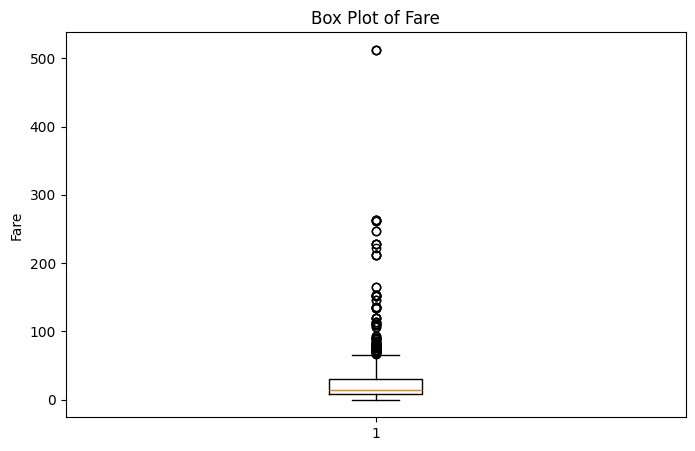

In [5]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Fare"].dropna())
plt.title("Box Plot of Fare")
plt.ylabel("Fare")
plt.show()

Explain:

Middle line → Median
Box → IQR
Whiskers → Data Range
Points outside → Outliers

# Scatter Plot

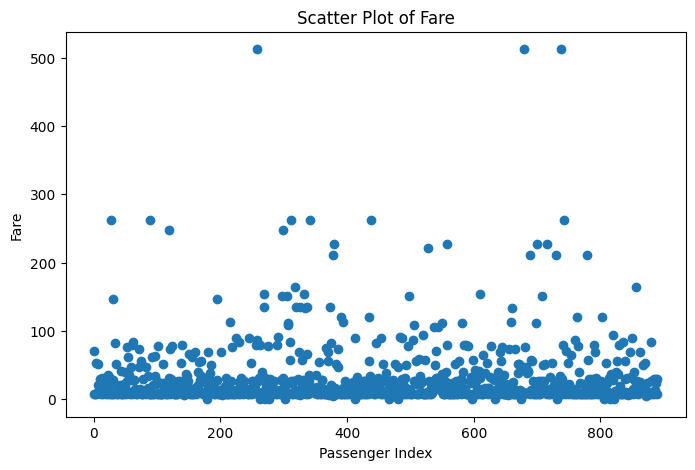

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df.index, df["Fare"])
plt.title("Scatter Plot of Fare")
plt.xlabel("Passenger Index")
plt.ylabel("Fare")
plt.show()

## Detect Outliers Using IQR

In [7]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

7.9104
31.0
23.0896


In [8]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-26.724
65.6344


In [9]:
outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]

outliers.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C


In [10]:
len(outliers)

116

## 📌 Remove Outliers

In [11]:
df_clean = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

df_clean.shape

(775, 12)

## 📌 Detect Outliers Using Z-Score

In [12]:
from scipy.stats import zscore

z_scores = zscore(df["Fare"].dropna())

z_scores[:10]

array([-0.50244517,  0.78684529, -0.48885426,  0.42073024, -0.48633742,
       -0.47811643,  0.39581356, -0.22408312, -0.42425614, -0.0429555 ])

Identify Outliers

In [13]:
abs(z_scores) > 3

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False,

## 🛠 Methods to Handle Outliers

- Remove Outliers
- Capping (Winsorization)
- Log Transformation
- Square Root Transformation
- Robust Scaling

## 🔍 Observations

- The Fare column contains several high-value outliers.
- Box plots quickly highlight extreme values.
- IQR is effective for skewed data.
- Z-Score works best for approximately normal distributions.

## ✅ Best Practices

- Investigate outliers before removing them.
- Do not assume every outlier is an error.
- Use IQR for skewed distributions.
- Use Z-Score for approximately normal distributions.
- Validate the impact of outlier treatment on model performance.

## 🌍 Real-World Scenario

In a retail company, most purchases range between ₹500 and ₹10,000. A transaction worth ₹5,00,000 appears in the dataset. Before removing it, analysts verify whether it is a genuine bulk purchase or a data entry error. This investigation prevents the loss of valuable business information while maintaining data quality.

## 📝 Summary

In this notebook, we learned how to detect and handle outliers using visualization techniques, the IQR method, and the Z-Score method. Proper treatment of outliers improves the quality of analysis and helps build more reliable machine learning models.